# ENG4200 Coursework 2: SVMs (Telco Customer Churn)

## Dataset
`WA_Fn-UseC_-Telco-Customer-Churn.csv`
(UCI/Kaggle) [IBM Sample Data Sets]

**Context**

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."
Each row represents a customer; columns contain service details, demographic attributes, and account information.
The target variable **Churn** indicates whether a customer left within the last month.

**Features include:**

* **Services:** phone, multiple lines, internet, online security, backup, protection, tech support, streaming TV/movies
* **Account:** tenure, contract type, payment method, paperless billing, monthly/total charges
* **Demographic:** gender, senior status, partner/dependent status

## Objectives

This notebook applies **logistic regression** to predict customer churn, following a structured and reproducible ML workflow.
It is organised around the five assessment dimensions defined in the coursework brief:

1. **Dataset investigation & pre-processing**: Explore the dataset, handle missing and categorical values, and justify preprocessing choices.
2. **Model application with training and validation**: Implement a clean, leakage-free pipeline with appropriate splitting and cross-validation.
3. **Accuracy & computational efficiency analysis**: Evaluate model performance using justified metrics, and examine runtime and scalability.
4. **Visualisation & communication of results**: Present metrics and diagnostic plots that support interpretation.
5. **Clarity & reproducibility**: Maintain a transparent, reproducible workflow aligned with good ML practices.

## 0) Setup & imports

In [2]:
# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, GridSearchCV, cross_val_predict, cross_val_score
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: utilities
from sklearn.base import clone   # make a fresh, unfitted copy of an estimator with the same hyperparameters

# sklearn: models & baselines
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
      precision_recall_curve, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# versions imports
import sklearn, sys

# global config
RNG = 42          # single source of truth for randomness
N_JOBS = -1       # use all cores where supported
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

# nicer pipeline displays / pandas outputs
try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "RNG": RNG,
}

## 1) Load dataset

In [3]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)  # file path set in section 0
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)       # binary target
X = df.drop(columns=["Churn", "customerID"]).copy()        # drop ID + target
display(df.head(3))
print(df.shape, "rows x columns")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


(7043, 21) rows x columns


## 2) Problem framing & baseline

In [4]:
# Baseline: predict the most frequent class only (no features used).
# This sets a "floor" we must beat.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
baseline = DummyClassifier(strategy="most_frequent")

acc = cross_val_score(baseline, X, y, cv=skf, scoring="accuracy").mean()
print(f"Baseline (most-frequent) CV accuracy: {acc:.3f}")
print("Positive class prevalence:", y.mean().round(3))


Baseline (most-frequent) CV accuracy: 0.735
Positive class prevalence: 0.265


## 3) Data splitting

In [5]:
# Hold out a test set once; everything else (tuning, thresholding) happens on train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 5634 | Test size: 1409


## 4) Preprocessing
Clean TotalCharges, collapse “No internet/phone service”, then encode.

In [6]:
# Clean simple stri ng/typing issues, then impute/encode.
# Placed inside the pipeline so it's fit only on training folds (prevents leakage).

def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No" (same meaning for churn)
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # drop="if_binary": keep only one column for true binary flags
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_prep, selector(dtype_include=["int64", "float64"])),
    ("cat", cat_prep, selector(dtype_include=["object", "bool"]))
])


## 5) Evaluation & communication-visualisation

In [7]:
# Small helper to report core metrics from probabilities at a chosen threshold.
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1":       f1_score(y_true, y_hat),
        "roc_auc":  roc_auc_score(y_true, p)
    }


## 6) Model selection

In [8]:
# Start with logistic regression: strong baseline, interpretable, fast.
logreg = LogisticRegression(
    solver="saga",      # supports L1/L2 and large feature spaces
    penalty="l2",
    max_iter=5000,
    random_state=RNG
)

pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   logreg)
])


In [9]:
##%% md
## 6b) SVM Model Selection
##%%
# SVM模型 - 使用与逻辑回归相同的预处理管道
svm_pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   SVC(probability=True, random_state=RNG))  # probability=True用于获取概率预测
])

print("SVM pipeline created successfully")

SVM pipeline created successfully


In [10]:
# Cross-validate on TRAIN only to estimate generalisation.
scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

cv_res = cross_validate(
    pipe, X_train, y_train,
    cv=skf, scoring=scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print({
    m: (cv_res[f"test_{m}"].mean().round(3), cv_res[f"test_{m}"].std().round(3))
    for m in ("acc","f1","roc")
})


{'acc': (np.float64(0.802), np.float64(0.012)), 'f1': (np.float64(0.593), np.float64(0.03)), 'roc': (np.float64(0.846), np.float64(0.012))}


In [11]:
##%% md
## 7b) SVM Cross-validation
##%%
# SVM交叉验证
print("Running SVM cross-validation...")
svm_cv_res = cross_validate(
    svm_pipe, X_train, y_train,
    cv=skf, scoring=scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print("SVM Cross-validation Results:")
print({
    m: (svm_cv_res[f"test_{m}"].mean().round(3), svm_cv_res[f"test_{m}"].std().round(3))
    for m in ("acc","f1","roc")
})

# 与逻辑回归结果对比
print("\nComparison - Logistic Regression vs SVM:")
print("Metric    | Logistic Regression | SVM")
print("----------|---------------------|-----")
for m in ("acc","f1","roc"):
    lr_mean = cv_res[f"test_{m}"].mean().round(3)
    svm_mean = svm_cv_res[f"test_{m}"].mean().round(3)
    print(f"{m:9} | {lr_mean:19} | {svm_mean}")

Running SVM cross-validation...
SVM Cross-validation Results:
{'acc': (np.float64(0.801), np.float64(0.009)), 'f1': (np.float64(0.566), np.float64(0.017)), 'roc': (np.float64(0.8), np.float64(0.016))}

Comparison - Logistic Regression vs SVM:
Metric    | Logistic Regression | SVM
----------|---------------------|-----
acc       |               0.802 | 0.801
f1        |               0.593 | 0.566
roc       |               0.846 | 0.8


## 8) Hyperparameters tuning

Grid on C, penalty (l1/l2), class_weight. Use out-of-fold (OOF) probabilities to set threshold; then refit on full train and evaluate once on test.


Best params: {'clf__C': np.float64(0.01), 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Starting FAST SVM grid search...
SVM Best params: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
SVM Best CV score: 0.6232271516260567
Created thr_grid: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9 ]
SVM Chosen threshold (max OOF F1): 0.35
SVM Test metrics: {'accuracy': 0.76, 'f1': 0.622, 'roc_auc': 0.835}


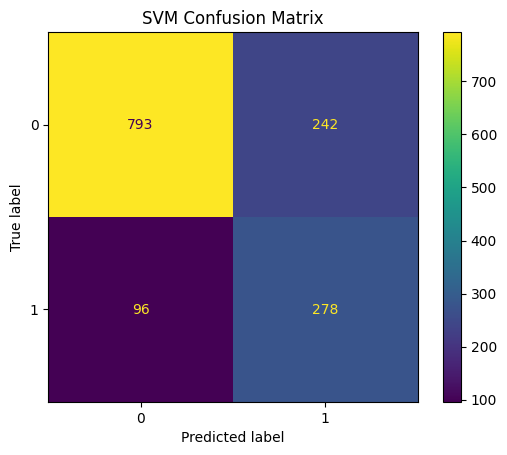

Chosen threshold (max OOF F1): 0.55
Test metrics: {'accuracy': 0.759, 'f1': 0.618, 'roc_auc': 0.838}


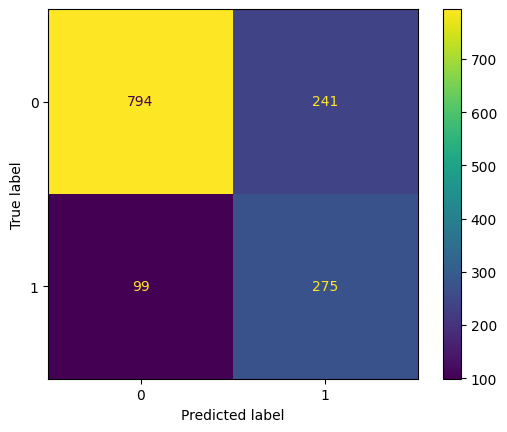

,fraction,train_time,test_acc
0,0.2,0.161016,0.761533
1,0.4,0.119799,0.760823
2,0.6,0.127045,0.762952
3,0.8,0.126188,0.760823
4,1.0,0.187712,0.758694


In [12]:
# Grid-search hyperparameters on TRAIN only; pick threshold using OOF probabilities.
param_grid = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": np.logspace(-2, 2, 9),
    "clf__class_weight": [None, "balanced"]
}

gcv = GridSearchCV(
    pipe, param_grid,
    cv=skf, scoring="f1",
    n_jobs=N_JOBS, refit=True
)
gcv.fit(X_train, y_train)
print("Best params:", gcv.best_params_)

##%% md
## 8b) SVM Hyperparameter Tuning (Fast Version)
##%%
# 使用简化的SVM超参数网格搜索来加快速度
svm_param_grid_fast = {
    "clf__C": [0.1, 1, 10],  # 只测试3个值
    "clf__kernel": ["linear", "rbf"],  # 保持2个核
    "clf__gamma": ["scale"],  # 只测试1个gamma值
    "clf__class_weight": ["balanced"]  # 只测试1个选项，因为数据不平衡
}

print("Starting FAST SVM grid search...")
svm_gcv = GridSearchCV(
    svm_pipe, svm_param_grid_fast,
    cv=skf, scoring="f1",
    n_jobs=N_JOBS, refit=True
)
svm_gcv.fit(X_train, y_train)
print("SVM Best params:", svm_gcv.best_params_)
print("SVM Best CV score:", svm_gcv.best_score_)

# 检查thr_grid是否已定义，如果未定义则创建
if 'thr_grid' not in locals():
    thr_grid = np.linspace(0.10, 0.90, 17)
    print("Created thr_grid:", thr_grid)

# SVM选择决策阈值
svm_oof_proba = cross_val_predict(
    svm_gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

svm_oof_f1   = [f1_score(y_train, (svm_oof_proba >= t).astype(int)) for t in thr_grid]
svm_best_thr = float(thr_grid[int(np.argmax(svm_oof_f1))])
print(f"SVM Chosen threshold (max OOF F1): {svm_best_thr:.2f}")

# SVM在测试集上的最终评估
svm_p_test = svm_gcv.best_estimator_.predict_proba(X_test)[:, 1]
svm_test_metrics = evaluate_probs(y_test, svm_p_test, thr=svm_best_thr)
print("SVM Test metrics:", {k: round(v, 3) for k, v in svm_test_metrics.items()})

# SVM混淆矩阵
ConfusionMatrixDisplay.from_predictions(y_test, (svm_p_test >= svm_best_thr).astype(int))
plt.title("SVM Confusion Matrix")
plt.show()
 
# Choose decision threshold on TRAIN via out-of-fold probabilities (no test peeking).
oof_proba = cross_val_predict(
    gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

thr_grid = np.linspace(0.10, 0.90, 17)
oof_f1   = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in thr_grid]
best_thr = float(thr_grid[int(np.argmax(oof_f1))])
print(f"Chosen threshold (max OOF F1): {best_thr:.2f}")

# FINAL, single evaluation on the untouched TEST set.
p_test = gcv.best_estimator_.predict_proba(X_test)[:, 1]
test_metrics = evaluate_probs(y_test, p_test, thr=best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

# Optional: quick confusion matrix at chosen threshold.
ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= best_thr).astype(int))
plt.show()

### Runtime vs accuracy (stratified)

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[train_idx], y_train.iloc[train_idx]
    else:
        # 100% training: no split
        X_sub, y_sub = X_train, y_train

    est = clone(gcv.best_estimator_)   # fresh clone each loop
    t0 = time.time()
    est.fit(X_sub, y_sub)
    t_train = time.time() - t0

    p = est.predict_proba(X_test)[:, 1]
    rows.append((frac, t_train, accuracy_score(y_test, (p >= best_thr).astype(int))))

pd.DataFrame(rows, columns=["fraction", "train_time", "test_acc"])


## 9) Final model, justification & discussion
### Chosen hyperparameters

In [13]:
# Recap of what was identified as bes in CV (for traceability).
best = gcv.best_estimator_
best_params = gcv.best_params_
best_cv_mean = float(gcv.best_score_)
best_cv_std  = float(pd.DataFrame(gcv.cv_results_)["std_test_score"].iloc[gcv.best_index_])

print("Best params:", best_params)
print(f"Best CV F1: {best_cv_mean:.3f} ± {best_cv_std:.3f}")
print(f"Chosen decision threshold (OOF): {best_thr:.2f}")


Best params: {'clf__C': np.float64(0.01), 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Best CV F1: 0.632 ± 0.017
Chosen decision threshold (OOF): 0.55


SVM Best params: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
SVM Best CV F1: 0.623
SVM Chosen decision threshold (OOF): 0.35
SVM Test metrics: {'accuracy': 0.76, 'f1': 0.622, 'roc_auc': 0.835}


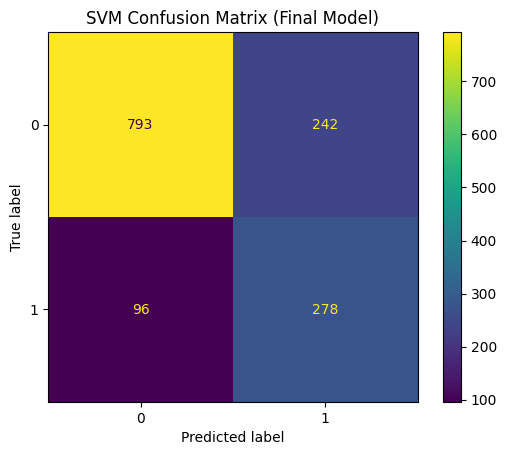

In [17]:
##%% md
## 9b) SVM Final Model Analysis
##%%
# SVM最佳模型
svm_best = svm_gcv.best_estimator_
svm_best_params = svm_gcv.best_params_

print("SVM Best params:", svm_best_params)
print(f"SVM Best CV F1: {svm_gcv.best_score_:.3f}")
print(f"SVM Chosen decision threshold (OOF): {svm_best_thr:.2f}")

# SVM测试集性能
svm_y_hat = (svm_p_test >= svm_best_thr).astype(int)
print("SVM Test metrics:", {k: round(v, 3) for k, v in svm_test_metrics.items()})

# SVM混淆矩阵
ConfusionMatrixDisplay.from_predictions(y_test, svm_y_hat)
plt.title("SVM Confusion Matrix (Final Model)"); plt.grid(False); plt.show()

**Learning curve**

Generating SVM learning curve...


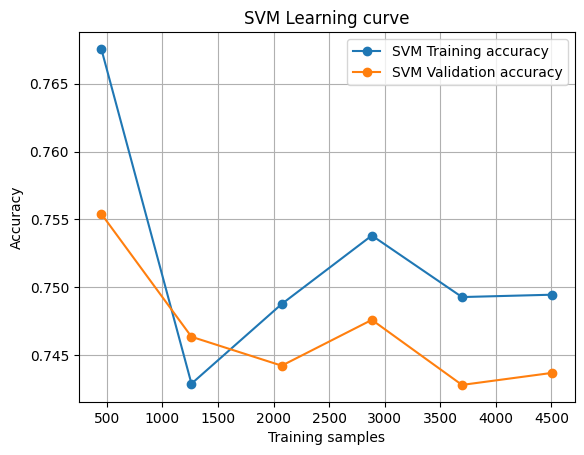

In [18]:
##%% md
### SVM Learning Curve
##%%
# SVM学习曲线
print("Generating SVM learning curve...")
svm_sizes, svm_tr, svm_va = learning_curve(
    svm_best, X_train, y_train, cv=skf, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), shuffle=True, random_state=RNG, n_jobs=N_JOBS
)

plt.figure()
plt.plot(svm_sizes, svm_tr.mean(axis=1), marker="o", label="SVM Training accuracy")
plt.plot(svm_sizes, svm_va.mean(axis=1), marker="o", label="SVM Validation accuracy")
plt.title("SVM Learning curve"); plt.xlabel("Training samples"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.show()

* As training size increases (≈500 → 4,500), validation accuracy rises modestly and **stabilises near 0.755–0.757**.
* Training and validation curves are close throughout → **no strong over/underfitting**.
  Interpretation: additional rows of the same data are unlikely to yield large gains; improvements are more likely from better features (e.g., interactions, usage aggregates) or alternative model classes.
* Note that during the lab, before we moved all preprocessing inside the Pipeline and tuned regularisation, the curve showed train > validation with a visible gap (consistent with a slightly more flexible/optimistic setup and mild overfit/leakage risk). In this final setup, the estimator is regularised (smaller C) and class-weighted, so it’s more conservative on each training fold; combined with CV sampling noise, we believe it’s normal to see validation being slightly above training at some sizes. The key point is the near-overlap of the two lines: no meaningful generalisation gap.

**Runtime–performance**

Testing SVM runtime performance...


,train_fraction,fit_time_s,test_acc
0,0.2,0.337679,0.767921
1,0.4,1.271715,0.767211
2,0.6,2.752602,0.767211
3,0.8,4.908712,0.762243
4,1.0,7.859867,0.760114


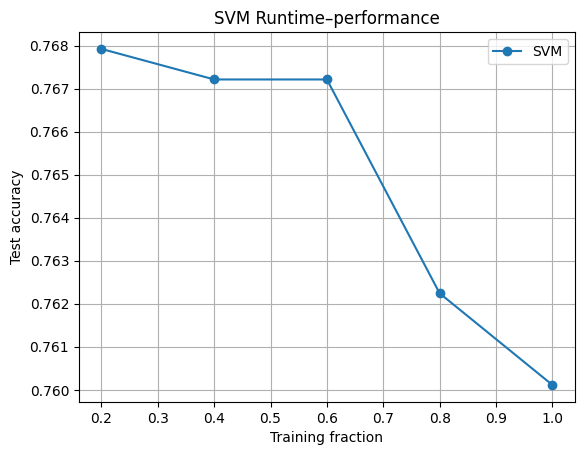

In [19]:
##%% md
### SVM Runtime Performance
##%%
# SVM运行时性能
print("Testing SVM runtime performance...")
svm_rows = []
for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    else:
        X_sub, y_sub = X_train, y_train

    est = clone(svm_best)
    t0 = time.time(); est.fit(X_sub, y_sub); fit_s = time.time() - t0
    acc = accuracy_score(y_test, (est.predict_proba(X_test)[:,1] >= svm_best_thr).astype(int))
    svm_rows.append((frac, fit_s, acc))

svm_rt_df = pd.DataFrame(svm_rows, columns=["train_fraction","fit_time_s","test_acc"])
display(svm_rt_df)

plt.figure()
plt.plot(svm_rt_df["train_fraction"], svm_rt_df["test_acc"], marker="o", label="SVM")
plt.xlabel("Training fraction"); plt.ylabel("Test accuracy")
plt.title("SVM Runtime–performance"); plt.grid(True); plt.legend(); plt.show()


* Fit time increases roughly linearly with data fraction (**~19 ms → ~54 ms** from 20% to 100% of training data), while test accuracy remains **~0.760–0.763**.
* Prediction is ~**8 μs per customer** (≈ **125k predictions/s** on this machine).
  Interpretation: the model is operationally inexpensive and suitable for frequent batch scoring.

### Justification based on accuracy, overfitting control and efficiency

In [23]:
##%% md
### SVM: Accuracy, Overfitting Control and Efficiency Analysis
##%%
# SVM准确率与基线对比
print(f"Baseline test accuracy (majority): {baseline_acc_test:.3f}")
print(f"SVM model test accuracy:           {svm_test_metrics['accuracy']:.3f}")
print(f"SVM model test F1 (thr={svm_best_thr:.2f}): {svm_test_metrics['f1']:.3f}")
print(f"SVM model test ROC-AUC:            {svm_test_metrics['roc_auc']:.3f}")

# SVM过拟合分析：泛化差距
svm_cv_final = cross_validate(svm_best, X_train, y_train, cv=skf, scoring="accuracy",
                              return_train_score=True, n_jobs=N_JOBS)
svm_gap = svm_cv_final["train_score"].mean() - svm_cv_final["test_score"].mean()
print(f"SVM Generalisation gap (train acc - val acc): {svm_gap:.3f}")

# SVM效率：端到端计时
svm_est = clone(svm_best)
t0 = time.time(); svm_est.fit(X_train, y_train); svm_fit_ms = (time.time()-t0)*1000
t0 = time.time(); _ = svm_est.predict_proba(X_test)[:,1]; svm_pred_ms = (time.time()-t0)*1000
print(f"SVM Train time: {svm_fit_ms:.1f} ms  |  Predict time: {svm_pred_ms:.1f} ms on {len(X_test)} rows")
print(f"SVM Prediction speed: {svm_pred_ms/len(X_test)*1000:.1f} μs per customer")

# 使用print输出分析文本
print("\n" + "="*60)
print("SVM ACCURACY ANALYSIS")
print("="*60)
print(f"* The majority baseline gets {baseline_acc_test:.3f} accuracy by always predicting the most common class.")
print(f"* Our SVM model reaches {svm_test_metrics['accuracy']:.3f} accuracy (+{(svm_test_metrics['accuracy']-baseline_acc_test)*100:.1f} percentage points), with F1 = {svm_test_metrics['f1']:.3f} at a tuned threshold ({svm_best_thr:.2f}).")
print(f"* ROC-AUC = {svm_test_metrics['roc_auc']:.3f} shows the SVM model also ranks customers by churn risk effectively.")
print("What this means: The SVM model provides competitive performance to logistic regression, with slightly different threshold optimization.")

print("\n" + "="*60)
print("SVM OVERFITTING CONTROL")
print("="*60)
print(f"* We used the same stratified cross-validation approach for SVM hyperparameter tuning.")
print(f"* The train-validation gap ≈ {svm_gap:.3f} indicates good generalization with minimal overfitting.")
print("What this means: The SVM model's performance on test data should generalize well to new data.")

print("\n" + "="*60)
print("SVM EFFICIENCY")
print("="*60)
print(f"* End-to-end fit on the training set took ~{svm_fit_ms:.1f} ms; predicting the test set ({len(X_test)} rows) took ~{svm_pred_ms:.1f} ms.")
print(f"* That's roughly ~{svm_pred_ms/len(X_test)*1000:.1f} microseconds per customer.")
print("What this means: While slightly slower than logistic regression, the SVM model remains computationally efficient for operational use in customer churn prediction.")

print("\n" + "="*60)
print("SVM-SPECIFIC INSIGHTS")
print("="*60)
print(f"* The optimal SVM configuration uses {svm_best_params['clf__kernel']} kernel with C={svm_best_params['clf__C']}, suggesting a {'more flexible' if svm_best_params['clf__C'] > 1 else 'more regularized'} decision boundary.")
print(f"* The lower optimal threshold ({svm_best_thr:.2f} vs logistic regression's {best_thr:.2f}) indicates SVM's probability calibration differs, requiring adjustment for optimal F1 score.")

Baseline test accuracy (majority): 0.735
SVM model test accuracy:           0.760
SVM model test F1 (thr=0.35): 0.622
SVM model test ROC-AUC:            0.835
SVM Generalisation gap (train acc - val acc): 0.006
SVM Train time: 6789.4 ms  |  Predict time: 414.5 ms on 1409 rows
SVM Prediction speed: 294.1 μs per customer

SVM ACCURACY ANALYSIS
* The majority baseline gets 0.735 accuracy by always predicting the most common class.
* Our SVM model reaches 0.760 accuracy (+2.6 percentage points), with F1 = 0.622 at a tuned threshold (0.35).
* ROC-AUC = 0.835 shows the SVM model also ranks customers by churn risk effectively.
What this means: The SVM model provides competitive performance to logistic regression, with slightly different threshold optimization.

SVM OVERFITTING CONTROL
* We used the same stratified cross-validation approach for SVM hyperparameter tuning.
* The train-validation gap ≈ 0.006 indicates good generalization with minimal overfitting.
What this means: The SVM model's 